In [1]:
import glob

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
data_files = [
    "/pscratch/sd/m/mahf708/ACE2-EAMv3/segment_01/atmosphere/monthly_mean_predictions.nc"
] + glob.glob(
    "/pscratch/sd/m/mahf708/ACE2-EAMv3/picontrol_run/seg_000[0123456789]/atmosphere/monthly_mean_predictions.nc"
) + glob.glob(
    "/pscratch/sd/m/mahf708/ACE2-EAMv3/picontrol_run/seg_001[01]/atmosphere/monthly_mean_predictions.nc"
)

In [3]:
solin = xr.open_dataset("/pscratch/sd/e/elynnwu/fme-dataset/2025-11-24-E3SMv3-piControl-100yr-coupled-IC/atmosphere-forcing-1yr.nc")["SOLIN"]

In [ ]:
mds = xr.open_mfdataset(
    data_files,
    combine="nested",
    concat_dim="time",
    drop_variables=["init_time"],
).isel(sample=0)

In [5]:
# replace the time coord with the valid_time variable, which is the actual time of the forecast
mds["time"] = mds.valid_time
mds = mds.drop_vars("valid_time")

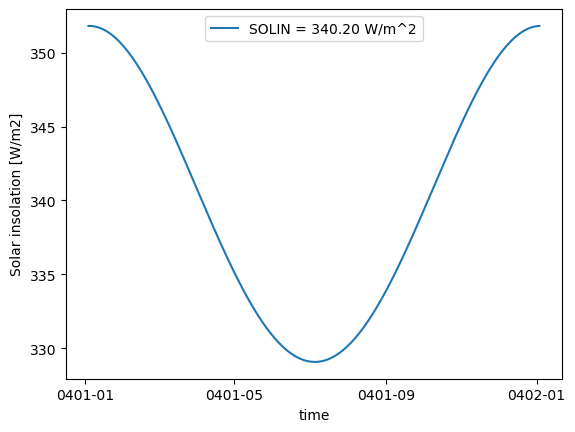

In [6]:
solin_mean = solin.weighted(np.cos(np.deg2rad(solin.lat))).mean(("lon", "lat"))
solin_mean.plot(label=f"SOLIN = {solin_mean.mean().item():.2f} W/m^2")
plt.legend()

In [7]:
solin_mean.mean().item()

340.2043467891269

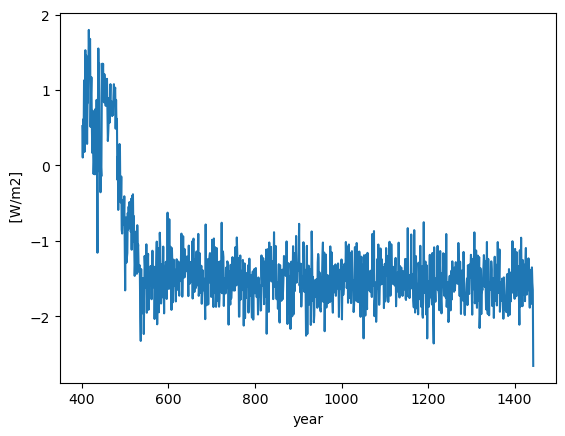

In [8]:
restom = (-mds.top_of_atmos_upward_shortwave_flux - mds.FLUT)                                                     
weights = np.cos(np.deg2rad(mds.lat))                                                                             
                                                                                                                
yearly_restom = (                                                                                                 
    restom      
    .weighted(weights)                                                                                            
    .mean(("lon", "lat"))
    .groupby("time.year")
    .mean("time")
    .compute()  # triggers actual computation once
)                                                                                                                 

(solin_mean.mean().item()+yearly_restom).plot(label="RESTOM")

In [9]:
mds

<xarray.Dataset> Size: 182GB
Dimensions:                                                      (time: 12519,
                                                                  lat: 180,
                                                                  lon: 360)
Coordinates:
  * time                                                         (time) object 100kB ...
  * lat                                                          (lat) float32 720B ...
  * lon                                                          (lon) float32 1kB ...
    counts                                                       (time) int64 100kB dask.array<chunksize=(1,), meta=np.ndarray>
Data variables: (12/56)
    FLDS                                                         (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    FSDS                                                         (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    surface_upward_longwave_flux                                 (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    top_of_atmos_upward_shortwave_flux                           (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    FLUT                                                         (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    surface_precipitation_rate                                   (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    ...                                                           ...
    V_3                                                          (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    specific_total_water_5                                       (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    total_water_path_budget_residual                             (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    net_energy_flux_sfc_into_atmosphere                          (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    TAUY                                                         (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    T_1                                                          (time, lat, lon) float32 3GB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    source.git_sha:   7943fe4f7
    source.job_id:    None
    history.created:  2026-03-21T14:42:46.284530
    title:            ACE monthly mean predictions data file

In [ ]:
restom = (-mds.top_of_atmos_upward_shortwave_flux - mds.FLUT)                                                     
weights = np.cos(np.deg2rad(mds.lat))                                                                             
                                                                                                                
yearly_restom = (                                                                                                 
    restom      
    .weighted(weights)                                                                                            
    .mean(("lon", "lat"))
    .groupby("time.year")
    .mean("time")
    .compute()  # triggers actual computation once
)                                                                                                                 

(solin_mean.mean().item()+yearly_restom).plot(label="RESTOM")

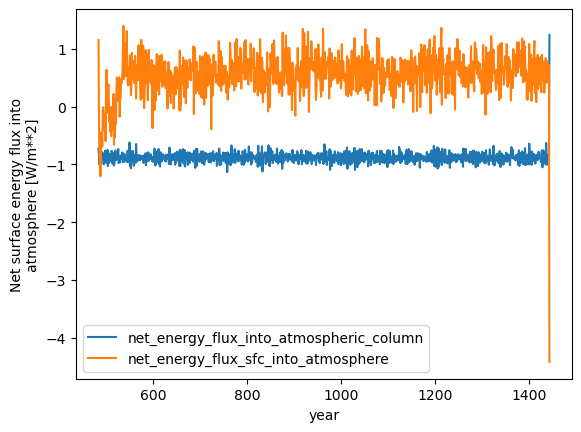

In [11]:
net_energy_flux_into_atmospheric_column_year = (
    mds.net_energy_flux_into_atmospheric_column
    .weighted(weights)
    .mean(("lon", "lat"))
    .groupby("time.year")
    .mean("time")
    .compute()
)
net_energy_flux_sfc_into_atmosphere_year = (
    mds.net_energy_flux_sfc_into_atmosphere
    .weighted(weights)
    .mean(("lon", "lat"))
    .groupby("time.year")
    .mean("time")
    .compute()
)
net_energy_flux_into_atmospheric_column_year.plot(label="net_energy_flux_into_atmospheric_column")
net_energy_flux_sfc_into_atmosphere_year.plot(label="net_energy_flux_sfc_into_atmosphere")
plt.legend()